# L-OPLS, and refitting OPLS torsions by gradient descent

OPLS-AA was parameterized on *short* alkanes, and it overestimates the
hydrocarbon gauche-trans energy gap — enough that long alkanes and lipid
tails freeze into a gel far above their experimental melting points. L-OPLS
(Siu, Pluhackova & Böckmann, *J. Chem. Theory Comput.* **8**, 1459, 2012)
fixed this by refitting the hydrocarbon torsions to MP2/aug-cc-pVTZ dihedral
scans of hexane (their Fig. 3), plus small nonbonded adjustments.

Because the `xnn` OPLS implementation is an ordinary differentiable PyTorch
module, that kind of reparameterization is a gradient-descent problem, in
exactly the same workflow used for ReaxFF refits. This notebook

1. compares the hexane central-torsion profile of **OPLS-AA** and the
   **L-OPLS** library shipped with `xnn` (`lopls.frc`, layered over the
   OPLS-AA distribution; the paper's headline figure). Both type the
   molecule from the SMARTS templates in their parameter files;
2. *re-derives* the L-OPLS `C-C-C-C` torsion (the `opls_18` alkane-carbon
   quadruple) from data: starting from OPLS-AA with
   `trainable=("dihedral_v",)`, the torsion Fourier coefficients are fit to
   reference conformer energies (here generated with the L-OPLS torsion
   standing in for the paper's MP2 scans);
3. exports the trained parameters back to a `.frc` force-field file and runs
   a short NVE trajectory as a sanity check.

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")
import math
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)
torch.manual_seed(0)
rng = np.random.default_rng(0)

from ase import Atoms, units
from ase.constraints import FixInternals
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase.md.verlet import VelocityVerlet
from ase.optimize import BFGS

import xnn
from xnn.common.data import collate, structure_to_graph
from xnn.common.deploy import XNNCalculator
from xnn.common.models import ForceStressOutput
from xnn.ffnn.models import OPLS, builtin_library
from xnn.ffnn.models.oplslib import KCAL_TO_EV

EV_TO_KJ = 96.48533212331
print("xnn:", xnn.__version__, "| torch:", torch.__version__)

xnn: 0.1.0 | torch: 2.5.1+cu121


## 1. Hexane with the two parameter sets

L-OPLS introduced per-connectivity nonbonded types (`lopls_CT_CH3`,
`lopls_HC_CH2`, ...) with adjusted charges and a softer methylene-hydrogen
epsilon, and refit torsions given in the paper's Table 2 — all of which the
built-in `"lopls"` library carries. Bonds and angles are the unchanged
OPLS-AA values.


In [2]:
def ideal_alkane(n, seed=42):
    """A rough all-anti alkane C_nH_{2n+2}: zig-zag backbone + jittered H."""
    r, ang = 1.529, math.radians(112.7)
    pos = [np.zeros(3)]
    up = True
    for _ in range(1, n):
        v = np.array([math.cos(ang / 2), (1 if up else -1) * math.sin(ang / 2), 0.0])
        pos.append(pos[-1] + r * v)
        up = not up
    jit = np.random.default_rng(seed)
    H, hb = [], []
    for i, p in enumerate(pos):
        for k in range(3 if i in (0, n - 1) else 2):
            phi = 2 * math.pi * k / 3 + 0.5 * i
            H.append(p + 1.09 * np.array([0.3 * (-1 if i == 0 else 1 if i == n - 1 else 0),
                                          0.7 * math.cos(phi), 0.9 * math.sin(phi)])
                     + 0.05 * jit.standard_normal(3))
            hb.append(i)
    z = [6] * n + [1] * len(H)
    bonds = [(i, i + 1) for i in range(n - 1)] + [(hb[k], n + k) for k in range(len(H))]
    return np.array(list(pos) + H), z, bonds, hb


pos0, z, bonds, hb = ideal_alkane(6)
# atom types come from each library's SMARTS templates; the topology is the
# same (derived from the bonds), only the type names differ
top = OPLS.from_atoms((pos0, z), "oplsaa", bonds=bonds).topology
top_lo = OPLS.from_atoms((pos0, z), "lopls", bonds=bonds).topology
print("OPLS-AA types:", sorted(set(top.types)))
print("L-OPLS types: ", sorted(set(top_lo.types)))
KEY = "opls_18-opls_18-opls_18-opls_18"    # the alkane C-C-C-C torsion
# the fragment rotated by the dihedral driver: everything past the C2-C3 bond
frag = [4, 5] + [6 + k for k in range(len(hb)) if hb[k] >= 3]
print(f"hexane: {len(top.dihedrals)} dihedrals, {len(top.pairs14)} 1,4 pairs")

OPLS-AA types: ['opls_80', 'opls_81', 'opls_85']
L-OPLS types:  ['lopls_CT_CH2', 'lopls_CT_CH3', 'lopls_HC_CH2', 'lopls_HC_CH3']
hexane: 45 dihedrals, 45 1,4 pairs


gauche-trans energy gap: OPLS-AA 5.10 kJ/mol, L-OPLS 1.88 kJ/mol
(Siu et al.: OPLS-AA ~4.5 kJ/mol, MP2 target / L-OPLS ~2.1 kJ/mol)


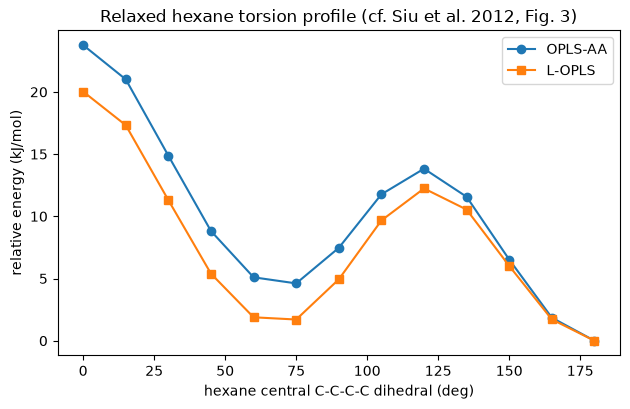

In [3]:
def relaxed_scan(topology, library, angles_deg, fmax=1e-5):
    """Relaxed scan of the central C-C-C-C dihedral (kJ/mol, relative)."""
    model = OPLS(library, topology, cutoff=50.0)
    calc = lambda: XNNCalculator(ForceStressOutput(model), cutoff=model.cutoff)
    ref = Atoms(numbers=z, positions=pos0 + 0.03 * rng.standard_normal((len(z), 3)))
    ref.calc = calc()
    BFGS(ref, logfile=None).run(fmax=fmax, steps=5000)
    energies = {}
    for a in angles_deg:
        w = ref.copy(); w.calc = calc()
        w.set_dihedral(1, 2, 3, 4, a, indices=frag)
        w.rattle(0.004, seed=2)         # break eclipsed-methyl saddle symmetry
        w.set_constraint(FixInternals(dihedrals_deg=[[a, [1, 2, 3, 4]]]))
        BFGS(w, logfile=None).run(fmax=fmax, steps=5000)
        energies[a] = w.get_potential_energy() * EV_TO_KJ
    e0 = min(energies.values())
    return {a: e - e0 for a, e in energies.items()}


angles = list(range(0, 181, 15))
prof_aa = relaxed_scan(top, builtin_library("oplsaa"), angles)
prof_lo = relaxed_scan(top_lo, builtin_library("lopls"), angles)

print(f"gauche-trans energy gap: OPLS-AA {prof_aa[60]:.2f} kJ/mol, "
      f"L-OPLS {prof_lo[60]:.2f} kJ/mol")
print("(Siu et al.: OPLS-AA ~4.5 kJ/mol, MP2 target / L-OPLS ~2.1 kJ/mol)")
assert 1.5 < prof_lo[60] < 2.6 and prof_aa[60] > 4.0

fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.plot(angles, [prof_aa[a] for a in angles], "o-", label="OPLS-AA")
ax.plot(angles, [prof_lo[a] for a in angles], "s-", label="L-OPLS")
ax.set_xlabel("hexane central C-C-C-C dihedral (deg)")
ax.set_ylabel("relative energy (kJ/mol)")
ax.set_title("Relaxed hexane torsion profile (cf. Siu et al. 2012, Fig. 3)")
ax.legend()
fig.tight_layout()
fig.savefig("opls_lopls_hexane_profiles.png", dpi=150)
plt.show()

The halved gauche-trans gap is the entire L-OPLS story: OPLS-AA's ~4.5
kJ/mol overpopulates *trans*, packing long chains into a gel; L-OPLS's ~2
kJ/mol matches the MP2 reference and keeps liquid alkanes liquid.

## 2. Reference data for the refit

The paper fit the torsion to MP2/aug-cc-pVTZ energies of hexane
conformations. To make this notebook self-contained *and* give the fit a
known right answer, the reference energies are generated with a "reference
potential": OPLS-AA with only its `CT-CT-CT-CT` torsion replaced by the
L-OPLS one. The training set is 48 hexane conformations — rigid rotations
of the central dihedral every 15° plus Gaussian jitter, the same kind of
coverage an *ab initio* scan provides.


In [4]:
ref_lib = builtin_library("oplsaa")
ref_lib.dihedral_types[KEY] = dict(builtin_library("lopls").dihedral_types[KEY])
reference = OPLS(ref_lib, top, cutoff=30.0)

# relaxed OPLS-AA hexane as the base geometry
base_model = OPLS("oplsaa", top, cutoff=30.0)
base = Atoms(numbers=z, positions=pos0 + 0.03 * rng.standard_normal((len(z), 3)))
base.calc = XNNCalculator(ForceStressOutput(base_model), cutoff=30.0)
BFGS(base, logfile=None).run(fmax=1e-4, steps=3000)

graphs = []
for a in range(0, 360, 15):
    w = base.copy()
    w.set_dihedral(1, 2, 3, 4, a, indices=frag)
    for _ in range(2):
        p = w.get_positions() + 0.03 * rng.standard_normal((len(z), 3))
        graphs.append(structure_to_graph(
            {"pos": torch.tensor(p), "atomic_numbers": torch.tensor(z)},
            cutoff=30.0))
batch = collate(graphs)
target = reference(batch)["energy"].detach()
print(f"{batch.num_graphs} training conformations, "
      f"energy spread {float(target.max() - target.min()) * EV_TO_KJ:.1f} kJ/mol")

48 training conformations, energy spread 87.6 kJ/mol


## 3. Gradient-descent refit of `CT-CT-CT-CT`

`trainable=("dihedral_v",)` exposes the dihedral Fourier table to the
optimizer. Like the paper — which refit only the backbone torsion and kept
the hydrogen ones — a gradient mask restricts the update to the
`CT-CT-CT-CT` row. Everything else is a plain PyTorch loop on the energy
mean-squared error.


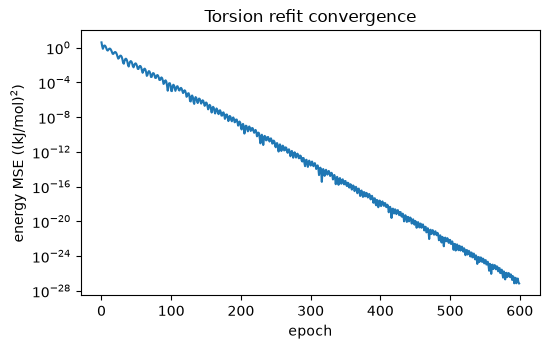

final RMSE: 2.65e-14 kJ/mol


In [5]:
model = OPLS("oplsaa", top, cutoff=30.0, trainable=("dihedral_v",))
row = model.ff.dihedral_keys.index(KEY)
mask = torch.zeros_like(model.ff.params["dihedral_v"])
mask[row] = 1.0
model.ff.params["dihedral_v"].register_hook(lambda g: g * mask)

opt = torch.optim.Adam([model.ff.params["dihedral_v"]], lr=2e-3)
losses = []
for epoch in range(600):
    opt.zero_grad()
    loss = (model(batch)["energy"] - target).pow(2).mean()
    loss.backward()
    opt.step()
    losses.append(float(loss))

fig, ax = plt.subplots(figsize=(5.6, 3.6))
ax.semilogy(np.array(losses) * EV_TO_KJ ** 2)
ax.set_xlabel("epoch")
ax.set_ylabel("energy MSE ((kJ/mol)$^2$)")
ax.set_title("Torsion refit convergence")
fig.tight_layout()
fig.savefig("opls_refit_loss.png", dpi=150)
plt.show()
print(f"final RMSE: {math.sqrt(losses[-1]) * EV_TO_KJ:.2e} kJ/mol")

In [6]:
learned = (model.ff.params["dihedral_v"][row] / KCAL_TO_EV).detach()
lopls_v = builtin_library("lopls").dihedral_types[KEY]["v"]
start_v = builtin_library("oplsaa").dihedral_types[KEY]["v"]
print(f"{'coefficient':<12} {'OPLS-AA start':>14} {'refit':>10} {'L-OPLS':>10}")
for k in range(5):
    print(f"V{k:<11} {start_v[k]:>14.4f} {float(learned[k]):>10.4f} "
          f"{lopls_v[k]:>10.4f}")
# V1..V4 are the physical coefficients; the constant V0 of the published RB
# form has no column in the .frc torsion form and is not in the reference
assert max(abs(float(learned[k]) - lopls_v[k]) for k in range(1, 5)) < 1e-3
print("\nthe refit recovers the published L-OPLS torsion (kcal/mol)")

coefficient   OPLS-AA start      refit     L-OPLS
V0                   0.0000     0.0000     0.0000
V1                   1.3000     0.6447     0.6447
V2                  -0.0500    -0.2143    -0.2143
V3                   0.2000     0.1782     0.1782
V4                   0.0000     0.0000     0.0000

the refit recovers the published L-OPLS torsion (kcal/mol)


The optimizer lands on the published L-OPLS Fourier coefficients to
essentially machine precision — including the constant `V0`, which L-OPLS
carries to make its Fourier and Ryckaert-Bellemans forms match exactly.
Against real *ab initio* data the loop is identical; only `target` changes
(and `xnn.common.train.Trainer` runs the same fit with batching,
validation and checkpoints).

## 4. Export, and an NVE sanity check

`export_library()` writes the trained tensors back to an `OPLSLibrary`
(kcal/mol, Angstrom, degrees), which round-trips through JSON. A short
microcanonical trajectory with the trained force field checks that the
refit potential is smooth and its autograd forces conserve energy.


In [7]:
os.makedirs("runs/opls_lopls_refit", exist_ok=True)
trained_lib = model.export_library()
trained_lib.name = "oplsaa-refit-cccc"
trained_lib.save_frc("runs/opls_lopls_refit/opls_trained.frc")   # standard .frc
trained_lib.save("runs/opls_lopls_refit/opls_trained.json")      # native JSON
print("saved runs/opls_lopls_refit/opls_trained.{frc,json}")
print("refit C-C-C-C:", [round(v, 4) for v in trained_lib.dihedral_types[KEY]["v"]])

saved runs/opls_lopls_refit/opls_trained.{frc,json}
refit C-C-C-C: [0.0, 0.6447, -0.2143, 0.1782, 0.0]


NVE, 1 ps @ 0.5 fs: total-energy drift +1.227 meV (fluctuation 0.517 meV), <T> = 135 K


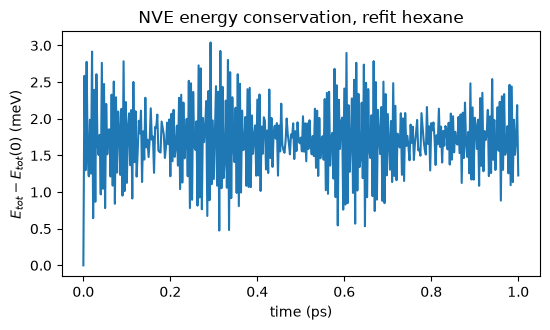

In [8]:
md_model = OPLS("runs/opls_lopls_refit/opls_trained.frc", top, cutoff=12.0)
atoms = base.copy()
atoms.calc = XNNCalculator(ForceStressOutput(md_model), cutoff=md_model.cutoff)
MaxwellBoltzmannDistribution(atoms, temperature_K=300, rng=np.random.default_rng(7))

dyn = VelocityVerlet(atoms, timestep=0.5 * units.fs)
etot, temps = [], []
def log():
    etot.append(atoms.get_potential_energy() + atoms.get_kinetic_energy())
    temps.append(atoms.get_temperature())
dyn.attach(log, interval=5)
dyn.run(2000)

etot = np.array(etot)
drift = (etot[-1] - etot[0]) * 1000
print(f"NVE, 1 ps @ 0.5 fs: total-energy drift {drift:+.3f} meV "
      f"(fluctuation {etot.std() * 1000:.3f} meV), <T> = {np.mean(temps):.0f} K")
assert abs(drift) < 2.0

fig, ax = plt.subplots(figsize=(5.6, 3.4))
ax.plot(np.arange(len(etot)) * 5 * 0.5 / 1000, (etot - etot[0]) * 1000)
ax.set_xlabel("time (ps)")
ax.set_ylabel(r"$E_{tot} - E_{tot}(0)$ (meV)")
ax.set_title("NVE energy conservation, refit hexane")
fig.tight_layout()
fig.savefig("opls_refit_nve.png", dpi=150)
plt.show()

## Summary

* The built-in `"lopls"` library reproduces the L-OPLS physics: the hexane
  gauche-trans gap drops from ~5 kJ/mol (OPLS-AA) to ~2 kJ/mol, the
  paper's central result.
* Refitting a torsion is a standard PyTorch loop: mark `dihedral_v`
  trainable, mask the rows to refit, minimize the energy MSE. The loop
  recovers the published L-OPLS `CT-CT-CT-CT` coefficients to machine
  precision from conformer energies alone.
* Trained parameters export back to a portable JSON library, and the refit
  force field conserves energy in NVE dynamics through `XNNCalculator`.
